# Импорты

In [1]:
!pip install -q catboost optuna xgboost lightgbm shap kaggle

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 97.1/97.1 MB 8.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 442.4/442.4 kB 21.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 268.7/268.7 kB 10.3 MB/s eta 0:00:00


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import balanced_accuracy_score, roc_auc_score, roc_curve

import optuna
from optuna.samplers import TPESampler

from catboost import CatBoostClassifier
import lightgbm as lgb
import xgboost as xgb
import shap

In [3]:
!kaggle competitions download -c gamma-knife-3

You must authenticate before you can call the Kaggle API.
Follow the instructions to authenticate at: https://github.com/Kaggle/kaggle-cli/blob/main/docs/README.md#authentication


In [4]:
import zipfile
import os

zip_path = "gamma-knife-3.zip"
extract_path = "gamma-knife-3"

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_path)

print("Готово, распаковано в папку:", extract_path)

Готово, распаковано в папку: gamma-knife-3


# EDA

In [5]:
df = pd.read_csv("gamma-knife-3/train.csv")
df_test = pd.read_csv("gamma-knife-3/test.csv")

df_test['Объем максимального очага'] = df_test['Объем максимального очага'].str.replace(',', '.').astype('float')
df_test['Суммарный объем очагов'] = df_test['Суммарный объем очагов'].str.replace(',', '.').astype('float')

In [6]:
dates = ['Дата рождения', 'Дата постановки онкологического диагноза / начала первичного лечения', 'Дата удаления первичного очага', 'Дата развития МГМ', 'Дата проведения ОВГМ', 'Дата операции на ГМ', 'Дата 1-ой РХ']

for date in dates:
  df[date] = pd.to_datetime(df[date], format = '%d.%m.%Y', errors = 'coerce')
  df_test[date] = pd.to_datetime(df_test[date], format = '%d.%m.%Y', errors = 'coerce')

In [7]:
df['Пол'] = df['Пол'].replace('м', 'М').replace('ж', 'Ж')

df['Мужчина'] = df['Пол'].apply(lambda x: 1 if x == 'М' else 0)

df.drop(columns = ['Пол'], axis = 1, inplace = True)

df_test['Пол'] = df_test['Пол'].replace('м', 'М').replace('ж', 'Ж')

df_test['Мужчина'] = df_test['Пол'].apply(lambda x: 1 if x == 'М' else 0)

df_test.drop(columns = ['Пол'], axis = 1, inplace = True)

In [8]:
df['Возраст'] = (df['Дата 1-ой РХ'] - df['Дата рождения']).dt.days / 365.25
df['Время_метастазирования'] = (df['Дата развития МГМ'] - df['Дата постановки онкологического диагноза / начала первичного лечения']).dt.days
df['Время_реагирования'] = (df['Дата 1-ой РХ'] - df['Дата развития МГМ']).dt.days

df['ОВГМ'] = df['Дата проведения ОВГМ'].notna().astype(int)
df['Операция'] = df['Дата операции на ГМ'].notna().astype(int)

df.drop(columns = ['Дата рождения', 'Дата развития МГМ', 'Дата постановки онкологического диагноза / начала первичного лечения', 'Дата проведения ОВГМ', 'Дата операции на ГМ', 'Дата 1-ой РХ', 'Дата удаления первичного очага'], axis = 1, inplace = True)

df_test['Возраст'] = (df_test['Дата 1-ой РХ'] - df_test['Дата рождения']).dt.days / 365.25
df_test['Время_метастазирования'] = (df_test['Дата развития МГМ'] - df_test['Дата постановки онкологического диагноза / начала первичного лечения']).dt.days
df_test['Время_реагирования'] = (df_test['Дата 1-ой РХ'] - df_test['Дата развития МГМ']).dt.days

df_test['ОВГМ'] = df_test['Дата проведения ОВГМ'].notna().astype(int)
df_test['Операция'] = df_test['Дата операции на ГМ'].notna().astype(int)

df_test.drop(columns = ['Дата рождения', 'Дата развития МГМ', 'Дата постановки онкологического диагноза / начала первичного лечения', 'Дата проведения ОВГМ', 'Дата операции на ГМ', 'Дата 1-ой РХ', 'Дата удаления первичного очага'], axis = 1, inplace = True)

In [9]:
df = df[df['Интракраниальная прогрессия'].notna()].copy()

df['Прогрессия'] = df['Интракраниальная прогрессия'].apply(
    lambda x: 1 if x in ['ДМ', 'ЛР+ДМ', 'ЛР'] else 0
)

df.drop(columns=['Интракраниальная прогрессия', 'Активирующие мутации'], inplace=True)

def create_procedure_flag(series):
    """
    Бинарный флаг события/процедуры:
    - 1 если значение задано и это НЕ 'нет'
      (например дата или любое другое "да/есть/..." значение)
    - 0 если NaN/пусто или явно 'нет'
    """
    s = series.astype(str).str.strip().str.lower()

    is_missing = s.isin(['nan', 'none', ''])
    is_no = s.eq('нет')

    return (~is_missing & ~is_no).astype(int)

df['Экстракраниальные метастазы'] = create_procedure_flag(df['Экстракраниальные метастазы'])

df_test.drop(columns=['Активирующие мутации'], inplace=True)
df_test['Экстракраниальные метастазы'] = create_procedure_flag(df_test['Экстракраниальные метастазы'])

In [10]:
df_encoded = df.copy()

In [11]:
df_encoded['Суммарный объем очагов'] = df_encoded['Суммарный объем очагов'].str.replace(',', '.').astype('float')

In [12]:
df_encoded = df_encoded[(df_encoded['Время_метастазирования'].notna().astype(int) == 1) & (df_encoded['Время_реагирования'].notna().astype(int) == 1)].copy()
df_encoded.drop(columns = ['Дистантные метастазы', 'Локальный рецидив'], axis = 1, inplace = True)

df_encoded['Объем на очаг'] = df_encoded['Суммарный объем очагов'] / df_encoded['Число очагов в ГМ']

df_test['Объем на очаг'] = df_test['Суммарный объем очагов'] / df_test['Число очагов в ГМ']

In [13]:
df_encoded = df_encoded[df_encoded['Время_реагирования'] >= 0].copy()


In [14]:
df_encoded.drop(columns = ['Объем максимального очага'], axis = 1, inplace = True)
df_test.drop(columns = ['Объем максимального очага'], axis = 1, inplace = True)


In [15]:
cat_cols = ['Онкологический диагноз', 'Лекарственное лечение']
for col in cat_cols:
    df_encoded[col] = df_encoded[col].fillna("Unknown")

for col in cat_cols:
    df_test[col] = df_test[col].fillna("Unknown")

### Новые признаки

Добавляю производные признаки (скорость метастазирования, суммарный объём очагов и др.). Деление на ноль в скоростях оставляю как NaN - бустинги обрабатывают пропуски нативно. Границы квантильных бинов и обрезку выбросов считаю по train и применяю к test, чтобы не было утечки.

In [16]:
df_encoded['Скорость_метастазирования'] = df_encoded['Суммарный объем очагов'] / df_encoded['Время_метастазирования']
df_encoded['Скорость_реагирования'] = df_encoded['Суммарный объем очагов'] / (df_encoded['Время_реагирования'] + 1)
df_encoded['Индекс_прогрессирования'] = df_encoded['Время_метастазирования'] - df_encoded['Время_реагирования']

df_test['Скорость_метастазирования'] = df_test['Суммарный объем очагов'] / df_test['Время_метастазирования']
df_test['Скорость_реагирования'] = df_test['Суммарный объем очагов'] / (df_test['Время_реагирования'] + 1)
df_test['Индекс_прогрессирования'] = df_test['Время_метастазирования'] - df_test['Время_реагирования']

_speed_cols = ['Скорость_метастазирования', 'Скорость_реагирования']
for _df in (df_encoded, df_test):
    _df[_speed_cols] = _df[_speed_cols].replace([np.inf, -np.inf], np.nan)

In [17]:
p_99_TM = df_encoded['Время_метастазирования'].quantile(0.99)
df_encoded['Время_метастазирования'] = df_encoded['Время_метастазирования'].apply(lambda x: 0 if x < 0 else (p_99_TM if x > p_99_TM else x))

p_99_TR = df_encoded['Время_реагирования'].quantile(0.99)
df_encoded['Время_реагирования'] = df_encoded['Время_реагирования'].apply(lambda x: 0 if x < 0 else (p_99_TR if x > p_99_TR else x))

p_99_SV = df_encoded['Суммарный объем очагов'].quantile(0.99)
df_encoded['Суммарный объем очагов'] = df_encoded['Суммарный объем очагов'].apply(lambda x: 0 if x < 0 else (p_99_SV if x > p_99_SV else x))

p_99_VM = df_encoded['Объем на очаг'].quantile(0.99)
df_encoded['Объем на очаг'] = df_encoded['Объем на очаг'].apply(lambda x: 0 if x < 0 else (p_99_VM if x > p_99_VM else x))

df_test['Время_метастазирования'] = df_test['Время_метастазирования'].apply(lambda x: 0 if x < 0 else (p_99_TM if x > p_99_TM else x))

df_test['Время_реагирования'] = df_test['Время_реагирования'].apply(lambda x: 0 if x < 0 else (p_99_TR if x > p_99_TR else x))

df_test['Суммарный объем очагов'] = df_test['Суммарный объем очагов'].apply(lambda x: 0 if x < 0 else (p_99_SV if x > p_99_SV else x))

df_test['Объем на очаг'] = df_test['Объем на очаг'].apply(lambda x: 0 if x < 0 else (p_99_VM if x > p_99_VM else x))

In [18]:
df_encoded['Суммарный объем очагов'] = np.log1p(df_encoded['Суммарный объем очагов'])
df_encoded['Объем на очаг'] = np.log1p(df_encoded['Объем на очаг'])
df_encoded['Время_метастазирования'] = np.log1p(df_encoded['Время_метастазирования'])
df_encoded['Время_реагирования'] = np.log1p(df_encoded['Время_реагирования'])

df_encoded['Возраст * число очагов'] = df_encoded['Возраст'] * df_encoded['Число очагов в ГМ']

df_test['Суммарный объем очагов'] = np.log1p(df_test['Суммарный объем очагов'])
df_test['Объем на очаг'] = np.log1p(df_test['Объем на очаг'])
df_test['Время_метастазирования'] = np.log1p(df_test['Время_метастазирования'])
df_test['Время_реагирования'] = np.log1p(df_test['Время_реагирования'])

df_test['Возраст * число очагов'] = df_test['Возраст'] * df_test['Число очагов в ГМ']

_, bin_edges = pd.qcut(
    df_encoded["Суммарный объем очагов"],
    q=[0, 0.25, 0.5, 0.75, 1.0],
    retbins=True,
    duplicates='drop'
)

labels = list(range(len(bin_edges) - 1))

df_encoded["Категория"] = pd.cut(
    df_encoded["Суммарный объем очагов"],
    bins=bin_edges,
    labels=labels,
    include_lowest=True
)

df_test["Категория"] = pd.cut(
    df_test["Суммарный объем очагов"],
    bins=bin_edges,
    labels=labels,
    include_lowest=True
)

min_label, max_label = labels[0], labels[-1]

mask_nan = df_test["Категория"].isna()
if mask_nan.any():
    df_test.loc[mask_nan & (df_test["Суммарный объем очагов"] <= bin_edges[0]), "Категория"] = min_label
    df_test.loc[mask_nan & (df_test["Суммарный объем очагов"] >= bin_edges[-1]), "Категория"] = max_label
    df_test["Категория"] = df_test["Категория"].fillna(min_label)

df_encoded["Категория"] = df_encoded["Категория"].astype(int)
df_test["Категория"] = df_test["Категория"].astype(int)

In [19]:
df_encoded

,Онкологический диагноз,Число РХ процедур на ГН,Индекс Карновского,Число очагов в ГМ,Суммарный объем очагов,Экстракраниальные метастазы,Лекарственное лечение,Мужчина,Возраст,Время_метастазирования,Время_реагирования,ОВГМ,Операция,Прогрессия,Объем на очаг,Скорость_метастазирования,Скорость_реагирования,Индекс_прогрессирования,Возраст * число очагов,Категория
0,НМРЛ,1,70,1,1.974081,0,Химиотерапия,1,62.436687,5.981414,5.267858,0,0,0,1.974081,0.015696,0.031959,202.0,62.436687,2
1,РП,3,70,1,0.307485,0,Таргетная терапия,1,62.023272,8.636042,7.178179,0,1,1,0.307485,0.000064,0.000202,3845.0,62.023272,0
2,Меланома,1,80,3,0.350657,1,Химиотерапия,1,52.298426,6.188264,4.867534,0,0,1,0.131028,0.000864,0.003231,357.0,156.895277,0
3,НМРЛ,1,60,4,2.000128,1,Химиотерапия,1,55.383984,5.198497,3.828641,0,0,0,0.954549,0.035500,0.138913,135.0,221.535934,2
4,КРР,1,80,3,1.871802,1,Таргетная терапия,0,53.188227,6.885510,6.298949,0,1,0,1.041454,0.005629,0.010110,434.0,159.564682,2
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
864,КРР,1,70,1,2.564949,1,Химиотерапия,1,59.096509,6.413459,3.555348,0,0,0,2.564949,0.019704,0.342857,575.0,59.096509,3
866,Меланома,3,80,19,1.108563,1,Таргетная терапия,0,35.879535,6.642487,0.000000,1,0,1,0.101511,0.002650,2.030000,766.0,681.711157,0
867,Меланома,1,70,12,2.358965,1,Unknown,1,29.667351,4.094345,3.465736,0,0,0,0.586860,0.162373,0.299375,28.0,356.008214,2
869,РП,1,70,4,1.241269,1,Таргетная терапия,0,55.364819,6.253829,3.737670,0,0,0,0.479335,0.004740,0.058571,478.0,221.459274,1


# Разделение данных

In [20]:
X = df_encoded.drop(columns=['Прогрессия'])
y = df_encoded['Прогрессия'].astype(int)

print("X shape:", X.shape, "| y mean:", y.mean())

X shape: (583, 19) | y mean: 0.6569468267581475


In [21]:
X_cb = X.copy()

for c in cat_cols:
    X_cb[c] = X_cb[c].astype("object")
    X_cb[c] = X_cb[c].where(X_cb[c].notna(), "Unknown").astype(str)

print("X_cb cat dtypes:")
print(X_cb[cat_cols].dtypes)

X_cb cat dtypes:
Онкологический диагноз    object
Лекарственное лечение     object
dtype: object


# Данные под Catboost и LightGBM

# Optuna подбор параметров

Для тюнинга использую облегчённую 3-fold кросс-валидацию; финальное обучение и OOF-предсказания - на 5-fold.

In [22]:
optuna.logging.set_verbosity(optuna.logging.WARNING)

CV = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)

X_cb = X_cb.reset_index(drop=True)
y = y.reset_index(drop=True)

def best_balanced_accuracy_from_oof(y_true, oof_probs):
    best = -1
    for t in np.linspace(0.05, 0.95, 181):
        best = max(best, balanced_accuracy_score(y_true, (oof_probs >= t).astype(int)))
    return best

def objective(trial):
    params = {
        "bootstrap_type": "Bernoulli",
        "iterations": trial.suggest_int("iterations", 1800, 2800),
        "learning_rate": trial.suggest_float("learning_rate", 0.01, 0.04, log=True),
        "depth": trial.suggest_int("depth", 7, 11),
        "l2_leaf_reg": trial.suggest_int("l2_leaf_reg", 5, 25),
        "min_data_in_leaf": trial.suggest_int("min_data_in_leaf", 20, 100),
        "random_strength": trial.suggest_float("random_strength", 0.5, 2.0),
        "subsample": trial.suggest_float("subsample", 0.6, 0.9),

        "task_type": "GPU",
        "devices": "0",
        "loss_function": "Logloss",
        "eval_metric": "Logloss",
        "random_seed": 42,
        "verbose": False,
    }

    oof = np.zeros(len(X_cb))

    for tr_idx, val_idx in CV.split(X_cb, y):
        model = CatBoostClassifier(**params)
        model.fit(
            X_cb.iloc[tr_idx], y.iloc[tr_idx],
            cat_features=cat_cols,
            eval_set=(X_cb.iloc[val_idx], y.iloc[val_idx]),
            early_stopping_rounds=100,
            verbose=False
        )
        oof[val_idx] = model.predict_proba(X_cb.iloc[val_idx])[:, 1]

    return best_balanced_accuracy_from_oof(y, oof)

study = optuna.create_study(direction="maximize", sampler=TPESampler(seed=42))
study.optimize(objective, n_trials=8, show_progress_bar=True)

print("Best OOF BA:", study.best_value)
print("Best params:", study.best_params)

  0%|          | 0/8 [00:00<?, ?it/s]

Best OOF BA: 0.7462075718015666
Best params: {'iterations': 2667, 'learning_rate': 0.0230095062132501, 'depth': 10, 'l2_leaf_reg': 5, 'min_data_in_leaf': 98, 'random_strength': 1.7486639612006325, 'subsample': 0.6637017332034828}


# CatBoost

In [23]:
X_cb = X_cb.reset_index(drop=True)
y = y.reset_index(drop=True)

CV_FINAL = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

best_params = study.best_params.copy()

best_params.update({
    "bootstrap_type": "Bernoulli",
    "task_type": "GPU",
    "devices": "0",
    "loss_function": "Logloss",
    "eval_metric": "Logloss",
    "random_seed": 42,
    "verbose": False,
    "od_type": "Iter",
})

oof_probs = np.zeros(len(X_cb), dtype=float)
models = []

for fold, (tr_idx, val_idx) in enumerate(CV_FINAL.split(X_cb, y), start=1):
    model = CatBoostClassifier(**best_params)
    model.fit(
        X_cb.iloc[tr_idx], y.iloc[tr_idx],
        cat_features=cat_cols,
        eval_set=(X_cb.iloc[val_idx], y.iloc[val_idx]),
        early_stopping_rounds=150,
        verbose=False
    )
    proba = model.predict_proba(X_cb.iloc[val_idx])[:, 1]
    oof_probs[val_idx] = proba
    models.append(model)
    print(f"Fold {fold} | AUC:", roc_auc_score(y.iloc[val_idx], proba))

best_th, best_bal = 0.5, -1.0
for t in np.linspace(0.05, 0.95, 181):
    bal = balanced_accuracy_score(y, (oof_probs >= t).astype(int))
    if bal > best_bal:
        best_bal, best_th = float(bal), float(t)

print("OOF AUC:", roc_auc_score(y, oof_probs))
print("Best threshold:", best_th)
print("Best OOF balanced accuracy:", best_bal)

Fold 1 | AUC: 0.7928571428571429
Fold 2 | AUC: 0.8892857142857141
Fold 3 | AUC: 0.7750000000000001
Fold 4 | AUC: 0.7944078947368423
Fold 5 | AUC: 0.812171052631579
OOF AUC: 0.8157963446475196
Best threshold: 0.6449999999999999
Best OOF balanced accuracy: 0.7560378590078329


# LightGBM — OOF + модели для инференса

In [24]:
X_lgb = X.copy()
for c in cat_cols:
    X_lgb[c] = X_lgb[c].astype("category")

X_lgb = X_lgb.reset_index(drop=True)
y_lgb = y.reset_index(drop=True)

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

oof_probs_lgb = np.zeros(len(X_lgb))
models_lgb = []

lgb_params = dict(
    n_estimators=4000,
    learning_rate=0.01,
    num_leaves=31,
    min_child_samples=20,
    subsample=0.9,
    colsample_bytree=0.9,
    reg_lambda=1.0,
    objective="binary",
    random_state=42,
)

for fold, (tr_idx, val_idx) in enumerate(CV.split(X_lgb, y_lgb), start=1):
    model = lgb.LGBMClassifier(**lgb_params)
    model.fit(
        X_lgb.iloc[tr_idx], y_lgb.iloc[tr_idx],
        eval_set=[(X_lgb.iloc[val_idx], y_lgb.iloc[val_idx])],
        eval_metric="auc",
        callbacks=[lgb.early_stopping(200, verbose=False)]
    )
    oof_probs_lgb[val_idx] = model.predict_proba(X_lgb.iloc[val_idx])[:, 1]
    models_lgb.append(model)
    print(f"Fold {fold} | LGB AUC:", roc_auc_score(y_lgb.iloc[val_idx], oof_probs_lgb[val_idx]))

print("\nCorr(CatBoost, LGBM) =", round(np.corrcoef(oof_probs, oof_probs_lgb)[0, 1], 4))
print("CatBoost OOF mean:", oof_probs.mean())
print("LGBM OOF mean:", oof_probs_lgb.mean())

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 306, number of negative: 160
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000246 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1359
[LightGBM] [Info] Number of data points in the train set: 466, number of used features: 19
[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.656652 -> initscore=0.648411
[LightGBM] [Info] Start training from score 0.648411
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best g

# XGBoost

In [25]:
X_xgb = X.copy()

for c in cat_cols:
    X_xgb[c] = X_xgb[c].astype("category")

X_xgb = X_xgb.reset_index(drop=True)
y_xgb = y.reset_index(drop=True)

X_xgb = X_xgb.replace([np.inf, -np.inf], np.nan)

num_cols = X_xgb.select_dtypes(include=["number"]).columns
X_xgb[num_cols] = X_xgb[num_cols].clip(-1e6, 1e6)

print("Has inf:", np.isinf(X_xgb[num_cols].to_numpy()).any())
print("NaN count:", np.isnan(X_xgb[num_cols].to_numpy()).sum())

CV = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
oof_probs_xgb = np.zeros(len(X_xgb), dtype=float)
models_xgb = []

params = {
    "objective": "binary:logistic",
    "eval_metric": "logloss",
    "max_depth": 6,
    "eta": 0.05,
    "subsample": 0.8,
    "colsample_bytree": 0.8,

    "tree_method": "hist",
    "device": "cuda",
    "max_cat_to_onehot": 16,
    "random_state": 42,
}

for fold, (tr_idx, val_idx) in enumerate(CV.split(X_xgb, y_xgb), start=1):
    dtrain = xgb.DMatrix(
        X_xgb.iloc[tr_idx],
        label=y_xgb.iloc[tr_idx],
        enable_categorical=True,
        missing=np.nan
    )
    dval = xgb.DMatrix(
        X_xgb.iloc[val_idx],
        label=y_xgb.iloc[val_idx],
        enable_categorical=True,
        missing=np.nan
    )

    model = xgb.train(
        params,
        dtrain,
        num_boost_round=800,
        evals=[(dval, "val")],
        verbose_eval=False
    )

    proba = model.predict(dval)
    oof_probs_xgb[val_idx] = proba
    models_xgb.append(model)
    print(f"Fold {fold} | XGB AUC:", roc_auc_score(y_xgb.iloc[val_idx], proba))

print("XGB oof mean:", oof_probs_xgb.mean())

Has inf: False
NaN count: 75
Fold 1 | XGB AUC: 0.7217532467532467
Fold 2 | XGB AUC: 0.8607142857142857
Fold 3 | XGB AUC: 0.7610389610389611
Fold 4 | XGB AUC: 0.7519736842105263
Fold 5 | XGB AUC: 0.7963815789473685
XGB oof mean: 0.6813553934465569


# Проверка корреляций моделей

In [26]:
print("Corr(CB, LGB) =", np.corrcoef(oof_probs, oof_probs_lgb)[0,1])
print("Corr(CB, XGB) =", np.corrcoef(oof_probs, oof_probs_xgb)[0,1])
print("Corr(LGB, XGB) =", np.corrcoef(oof_probs_lgb, oof_probs_xgb)[0,1])


Corr(CB, LGB) = 0.7572179052825772
Corr(CB, XGB) = 0.8041327483875772
Corr(LGB, XGB) = 0.6845461300930111


# Инференс: LightGBM (вероятности на тесте)

In [27]:
test_lgb = df_test[X.columns].copy()
for c in cat_cols:
    test_lgb[c] = test_lgb[c].fillna("Unknown").astype("category")

test_probs_lgb = np.mean([m.predict_proba(test_lgb)[:,1] for m in models_lgb], axis=0)
print("test_probs_lgb mean:", test_probs_lgb.mean())

test_probs_lgb mean: 0.6197485731345841


# Ансамблирование: подбор весов и порога по OOF

In [28]:
p_cb  = oof_probs.copy()
p_lgb = oof_probs_lgb.copy()
p_xgb = oof_probs_xgb.copy()
y_true = y.values if hasattr(y, "values") else np.asarray(y)

def search_weights_and_threshold(y_true, p_cb, p_lgb, p_xgb,
                                 step_w=0.02, th_grid=np.linspace(0.05, 0.95, 181)):
    best = (-1.0, None, None, None)
    for w_cb in np.arange(0.0, 1.0 + 1e-9, step_w):
        for w_lgb in np.arange(0.0, 1.0 - w_cb + 1e-9, step_w):
            w_xgb = 1.0 - w_cb - w_lgb
            if w_xgb < -1e-9:
                continue
            p = w_cb*p_cb + w_lgb*p_lgb + w_xgb*p_xgb

            for th in th_grid:
                pred = (p >= th).astype(int)
                ba = balanced_accuracy_score(y_true, pred)
                if ba > best[0]:
                    best = (float(ba), float(w_cb), float(w_lgb), float(th))
    return best

best_ba, w_cb, w_lgb, best_th = search_weights_and_threshold(
    y_true, p_cb, p_lgb, p_xgb,
    step_w=0.02,
    th_grid=np.linspace(0.05, 0.95, 181)
)

w_xgb = 1.0 - w_cb - w_lgb

print("Best OOF BA (triple blend):", best_ba)
print("Weights: w_cb =", round(w_cb,3), "| w_lgb =", round(w_lgb,3), "| w_xgb =", round(w_xgb,3))
print("Best threshold:", round(best_th,3))

Best OOF BA (triple blend): 0.7595104438642297
Weights: w_cb = 0.84 | w_lgb = 0.0 | w_xgb = 0.16
Best threshold: 0.695


# Инференс: CatBoost (вероятности на тесте)

In [29]:


test_cb = df_test[X.columns].copy()
for c in cat_cols:
    test_cb[c] = test_cb[c].astype("object").where(test_cb[c].notna(), "Unknown").astype(str)

test_probs_cb = np.mean([m.predict_proba(test_cb)[:,1] for m in models], axis=0)
print("test_probs_cb mean:", test_probs_cb.mean())


test_probs_cb mean: 0.6087148576787266


# Инференс: XGBoost (модели + вероятности на тесте)

In [30]:
test_xgb = df_test[X.columns].copy()
for c in cat_cols:
    test_xgb[c] = pd.Categorical(test_xgb[c], categories=X_xgb[c].cat.categories)

test_xgb = test_xgb.replace([np.inf, -np.inf], np.nan)
num_cols = test_xgb.select_dtypes(include=["number"]).columns
test_xgb[num_cols] = test_xgb[num_cols].clip(-1e6, 1e6)

dtest = xgb.DMatrix(test_xgb, enable_categorical=True, missing=np.nan)
test_probs_xgb = np.mean([m.predict(dtest) for m in models_xgb], axis=0)
print("test_probs_xgb mean:", test_probs_xgb.mean())

test_probs_xgb mean: 0.55434966


# SHAP и ROC

In [31]:
X_shap = X_cb.copy()
for c in cat_cols:
    X_shap[c] = X_shap[c].astype("object").where(X_shap[c].notna(), "Unknown").astype(str)

final_model = CatBoostClassifier(**best_params)
final_model.fit(X_shap, y, cat_features=cat_cols, verbose=False)

CatBoostClassifier(bootstrap_type='Bernoulli', depth=10, devices='0', eval_metric='Logloss', iterations=2667, l2_leaf_reg=5, learning_rate=0.0230095062132501, loss_function='Logloss', min_data_in_leaf=98, od_type='Iter', random_seed=42, random_strength=1.7486639612006325, subsample=0.6637017332034828, task_type='GPU', verbose=False)

### Важность признаков (SHAP)

Глобальная важность: средний вклад каждого признака в прогноз по всей выборке (bar), и как значения признаков двигают прогноз риска (beeswarm).

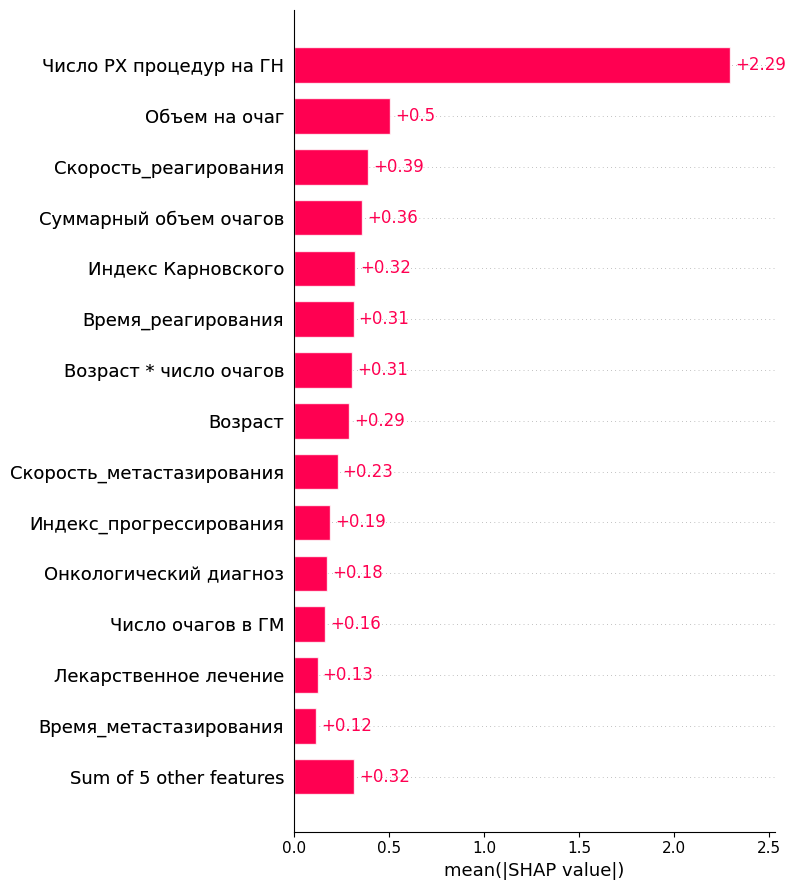

In [32]:
explainer = shap.TreeExplainer(final_model)

shap_values = explainer.shap_values(X_shap)

base_value = explainer.expected_value

exp = shap.Explanation(
    values=shap_values,
    base_values=np.full(len(X_shap), base_value),
    data=X_shap.values,
    feature_names=X_shap.columns.tolist()
)

fig, ax = plt.subplots(figsize=(12,6))
shap.plots.bar(
    exp,
    max_display=15,
    show=False
)
plt.tight_layout()
plt.savefig('shap_bar.png')
plt.show()

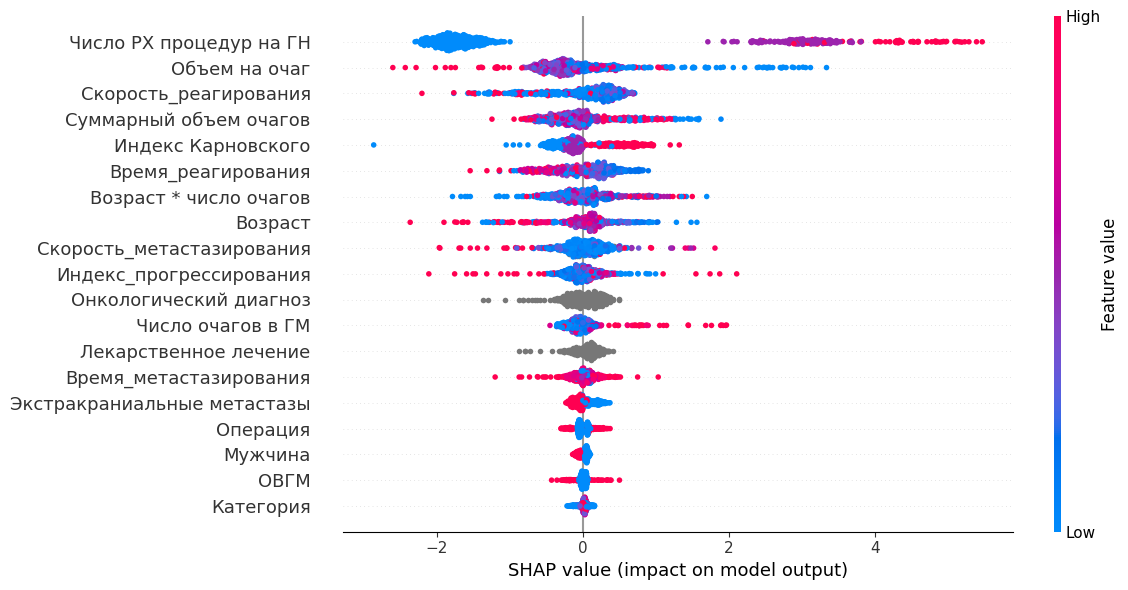

In [33]:
fig, ax = plt.subplots(figsize=(12,6))
shap.plots.beeswarm(
    exp,
    max_display=19,
    plot_size=(12, 6),
    show=False
)
plt.tight_layout()
plt.savefig('shap_beeswarm.png')
plt.show()

In [34]:
test_probs_blend = w_cb*test_probs_cb + w_lgb*test_probs_lgb + (1.0-w_cb-w_lgb)*test_probs_xgb

ths = [best_th-0.03, best_th-0.02, best_th-0.01, best_th, best_th+0.01, best_th+0.02, best_th+0.03]
ths = [float(np.clip(t, 0.05, 0.95)) for t in ths]

for t in ths:
    pred = (test_probs_blend >= t).astype(int)
    sub = pd.DataFrame({"ID": np.arange(1, len(pred)+1), "target": pred})
    fname = f"submission_triple_wcb{w_cb:.2f}_wlgb{w_lgb:.2f}_t{t:.3f}.csv"
    sub.to_csv(fname, index=False)
    print("Saved:", fname, "| positives=", round(pred.mean(), 3))

Saved: submission_triple_wcb0.84_wlgb0.00_t0.665.csv | positives= 0.409
Saved: submission_triple_wcb0.84_wlgb0.00_t0.675.csv | positives= 0.409
Saved: submission_triple_wcb0.84_wlgb0.00_t0.685.csv | positives= 0.386
Saved: submission_triple_wcb0.84_wlgb0.00_t0.695.csv | positives= 0.341
Saved: submission_triple_wcb0.84_wlgb0.00_t0.705.csv | positives= 0.341
Saved: submission_triple_wcb0.84_wlgb0.00_t0.715.csv | positives= 0.341
Saved: submission_triple_wcb0.84_wlgb0.00_t0.725.csv | positives= 0.341


### ROC-кривая

По OOF-предсказаниям CatBoost.

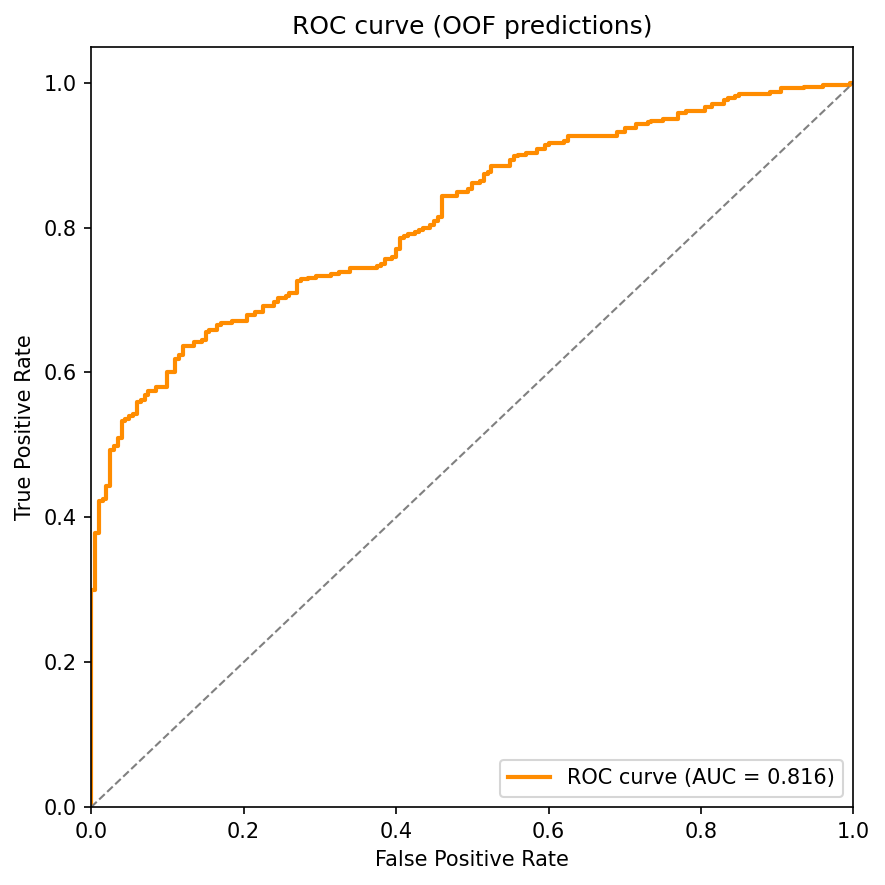

In [35]:
fpr, tpr, _ = roc_curve(y, oof_probs)
roc_auc = roc_auc_score(y, oof_probs)

plt.figure(figsize=(6, 6), dpi=150)

plt.plot(
    fpr, tpr,
    color="darkorange",
    lw=2,
    label=f"ROC-кривая (AUC = {roc_auc:.3f})"
)

plt.plot([0, 1], [0, 1], linestyle="--", color="gray", lw=1)

plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])

plt.xlabel("Доля ложноположительных (FPR)")
plt.ylabel("Доля истинноположительных (TPR)")
plt.title("ROC-кривая (OOF-предсказания)")
plt.legend(loc="lower right")

plt.tight_layout()

plt.savefig('roc_curve.png')

plt.show()

### Локальные объяснения (SHAP)

Waterfall для отдельных пациентов: какие признаки сформировали конкретный прогноз.

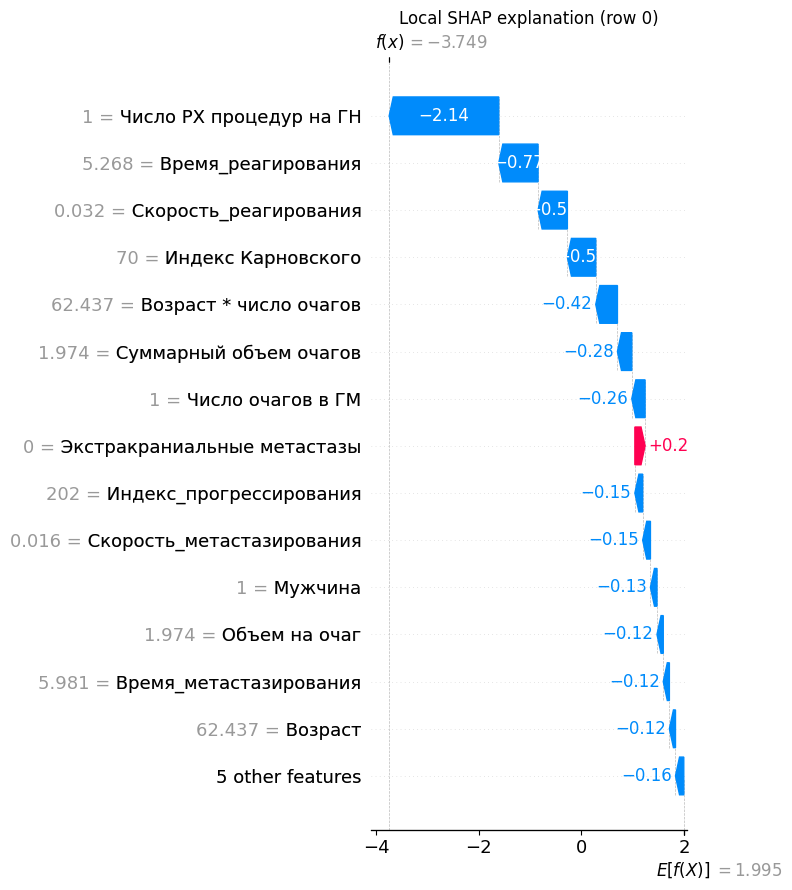

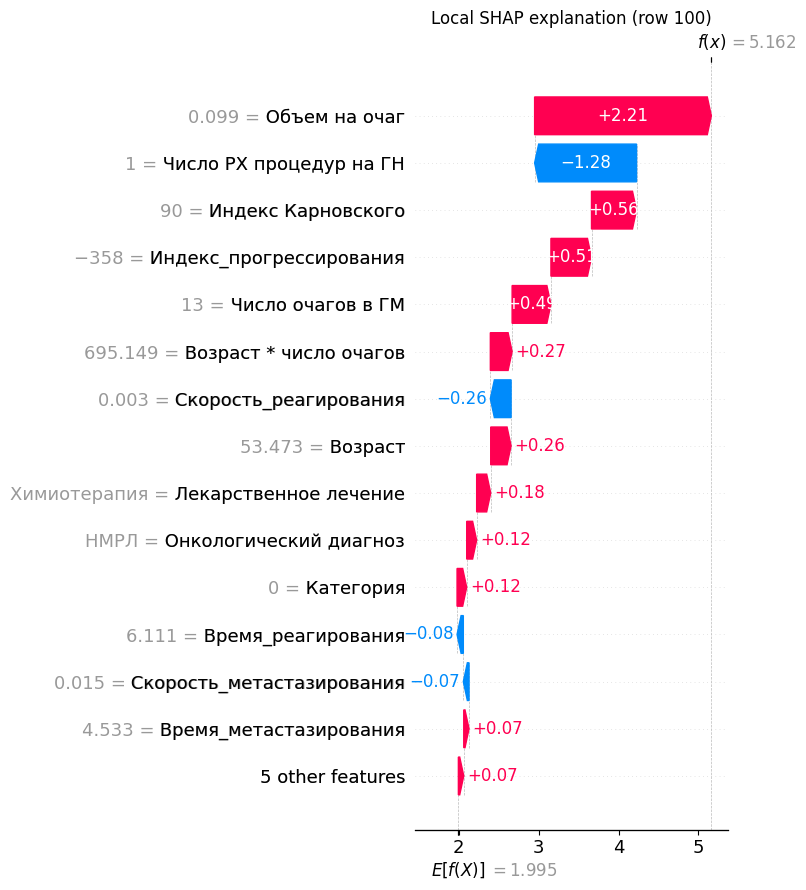

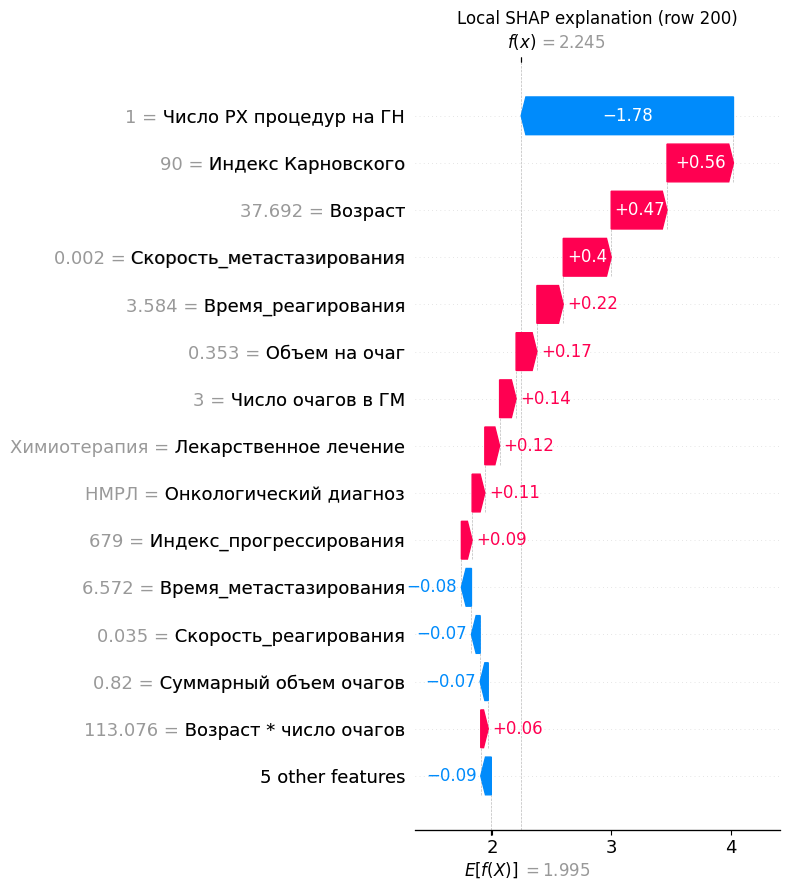

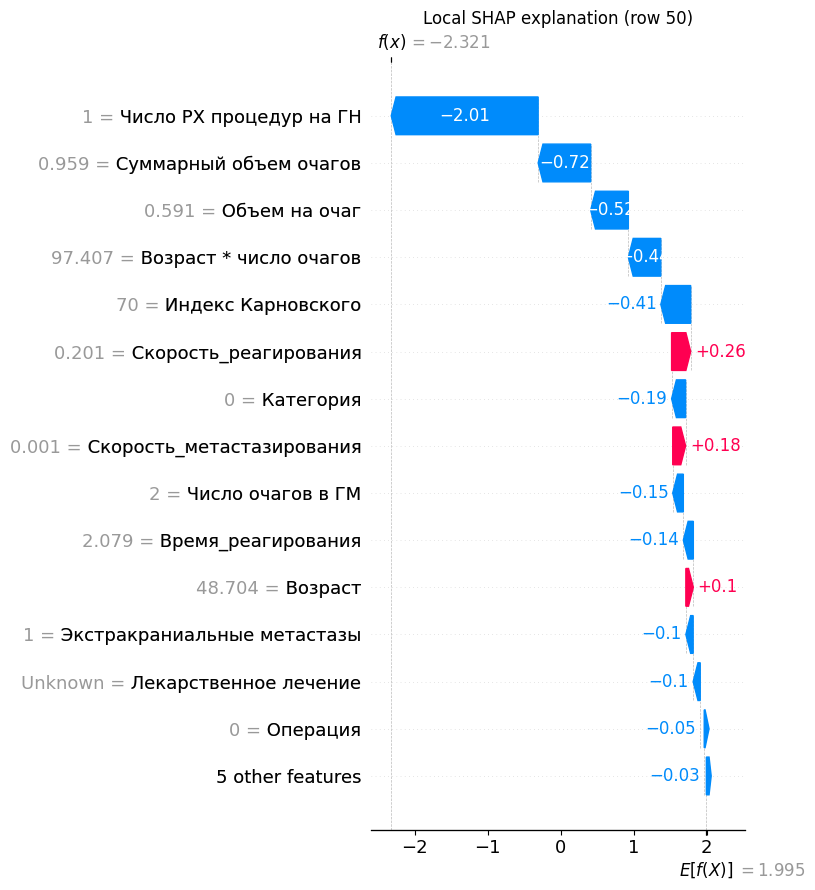

In [36]:
for row_id in [0, 100, 200, 50]:
    exp_one = shap.Explanation(
        values=shap_values[row_id],
        base_values=base_value,
        data=X_shap.iloc[row_id].values,
        feature_names=X_shap.columns.tolist()
    )

    plt.figure()
    shap.plots.waterfall(exp_one, max_display=15, show=False)
    plt.title(f"Локальное SHAP-объяснение (строка {row_id})")
    plt.tight_layout()
    plt.savefig(f'shap_waterfall_row{row_id}.png')
    plt.show()